# Food Price Analysis in Ethiopia - EDA

## Objective
To explore food price trends across Ethiopia, identify patterns, regional differences, and potentional inflation trends.

In [34]:
# Import nacessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# Read Data
df = pd.read_csv('../data/processed/cleaned.csv')

df.head()

,country,region,market,commodity,price_type,date,price,year,month
0,Ethiopia,Afar,Abaala,Barley,Retail,2020-01-15,1000.0,2020,1
1,Ethiopia,Afar,Abaala,Barley,Retail,2020-02-15,1000.0,2020,2
2,Ethiopia,Afar,Abaala,Barley,Retail,2023-08-15,9000.0,2023,8
3,Ethiopia,Afar,Abaala,Butter (cow milk),Retail,2026-01-15,1500.0,2026,1
4,Ethiopia,Afar,Abaala,Butter (goat milk),Retail,2026-01-15,900.0,2026,1


In [36]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54873 entries, 0 to 54872
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     54873 non-null  object 
 1   region      54873 non-null  object 
 2   market      54873 non-null  object 
 3   commodity   54873 non-null  object 
 4   price_type  54873 non-null  object 
 5   date        54873 non-null  object 
 6   price       54873 non-null  float64
 7   year        54873 non-null  int64  
 8   month       54873 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 3.8+ MB


,price,year,month
count,54873.000000,54873.000000,54873.000000
mean,4949.092767,2021.601862,6.124251
std,10020.150177,4.256186,3.390033
min,0.880000,2006.000000,1.000000
25%,90.000000,2020.000000,3.000000
50%,1600.000000,2023.000000,6.000000
75%,6000.000000,2025.000000,9.000000
max,270000.000000,2026.000000,12.000000


### Distribution of Price

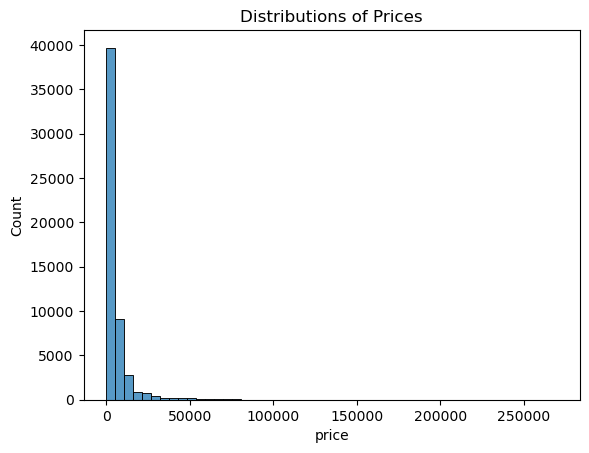

In [37]:
plt.figure()
sns.histplot(df['price'], bins=50)
plt.title('Distributions of Prices')
plt.show()

### Boxplot (Outliers)

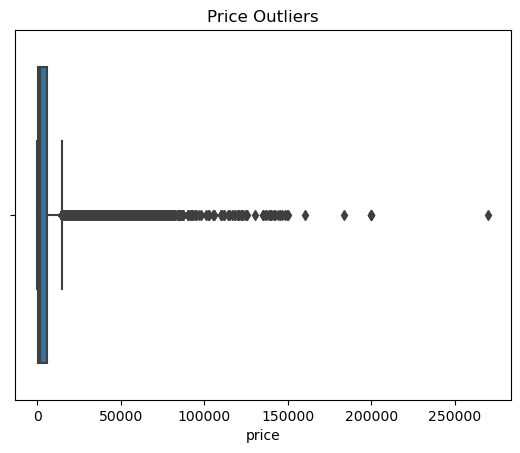

In [38]:
plt.figure()
sns.boxplot(x=df['price'])
plt.title("Price Outliers")
plt.show()

### Time Analysis

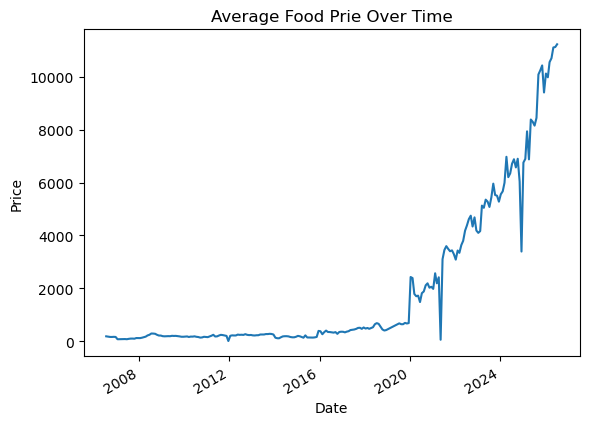

In [39]:
# Price trend over time

df['date'] = pd.to_datetime(df["date"])

price_trend = df.groupby("date")['price'].mean()

plt.figure()
price_trend.plot()
plt.title("Average Food Prie Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Monthly Trend 
##### For cleaner View

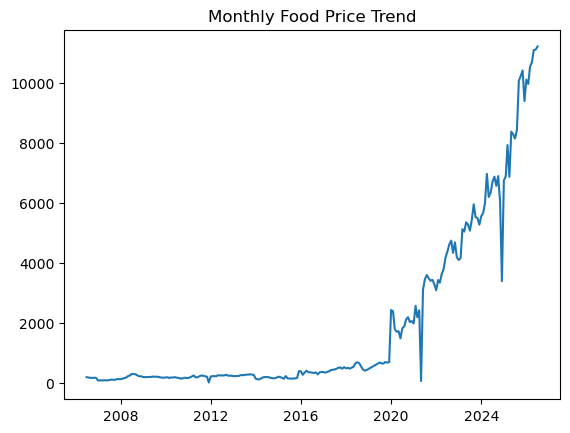

In [40]:
monthly = df.groupby(['year', 'month'])['price'].mean().reset_index()

monthly['date'] = pd.to_datetime(monthly[['year', "month"]].assign(day=1))

plt.figure()
plt.plot(monthly['date'], monthly['price'])
plt.title("Monthly Food Price Trend")
plt.show()

### Commodity Analysis

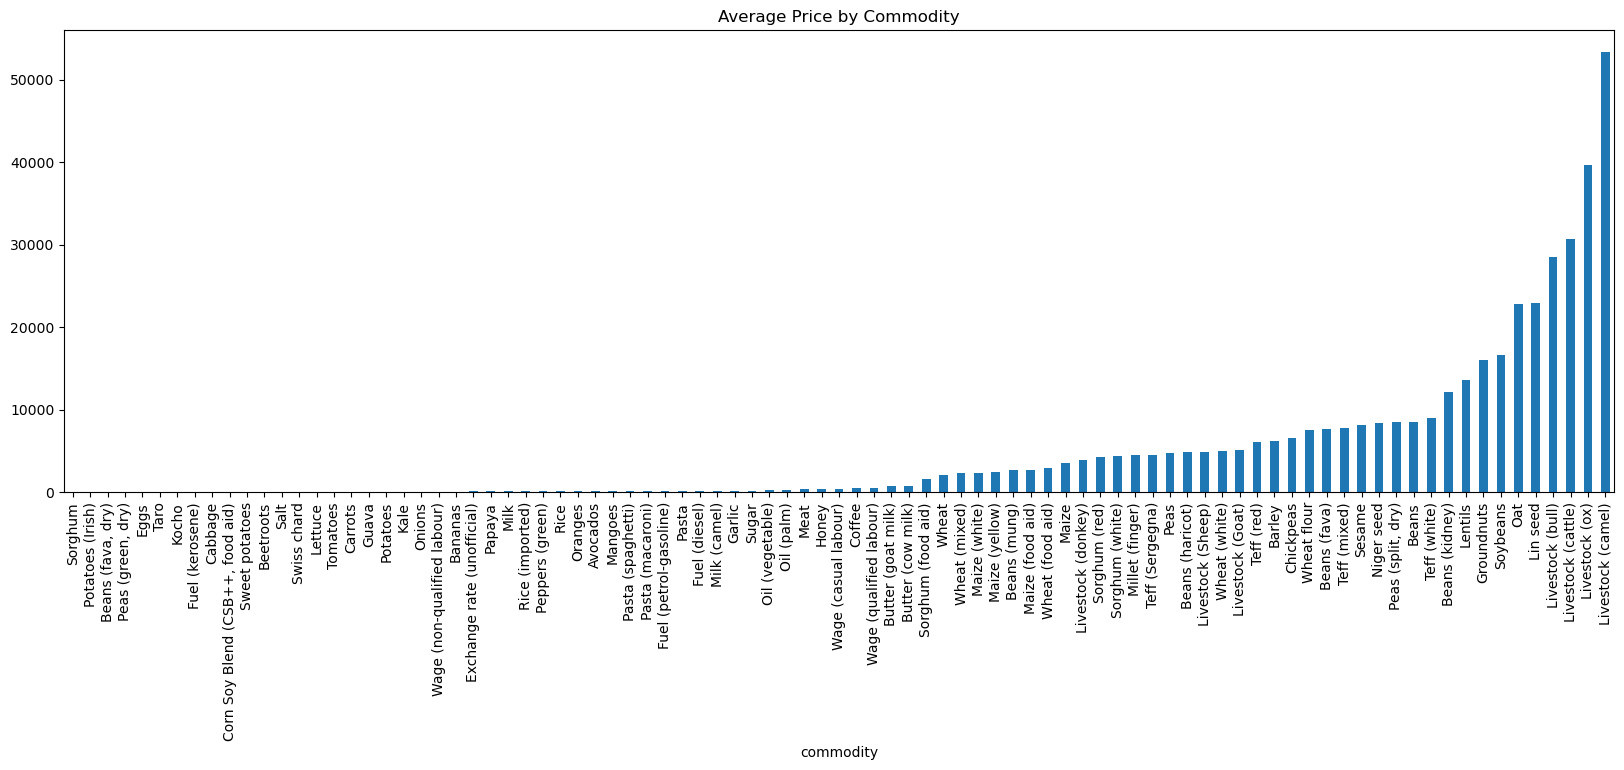

In [41]:
commodity_price = df.groupby("commodity")["price"].mean().sort_values()

plt.figure(figsize=(20, 6))
commodity_price.plot(kind="bar")
plt.title("Average Price by Commodity")
plt.show()

##### Top 10 Expensive Foods

In [42]:
commodity_price.sort_values(ascending=False).head(10)

commodity
Livestock (camel)     53353.307944
Livestock (ox)        39673.307177
Livestock (cattle)    30727.095581
Livestock (bull)      28531.788807
Lin seed              22893.000000
Oat                   22790.566038
Soybeans              16582.142857
Groundnuts            16054.322139
Lentils               13543.826510
Beans (kidney)        12140.000000
Name: price, dtype: float64

In [43]:
df['commodity'].describe()

count             54873
unique               89
top       Maize (white)
freq               6178
Name: commodity, dtype: object

### Regional Analysis

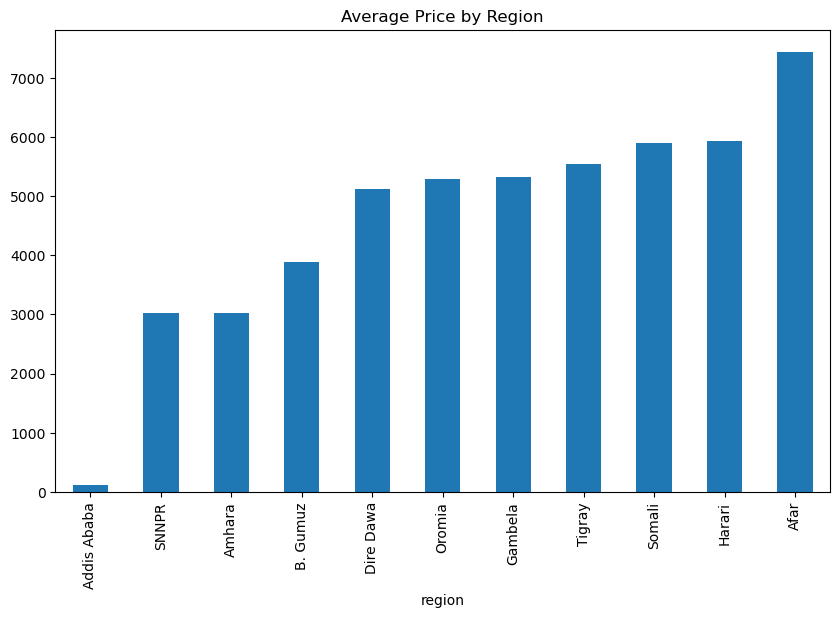

In [44]:
# Price by Region

region_price = df.groupby("region")["price"].mean().sort_values()

plt.figure(figsize=(10, 6))
region_price.plot(kind="bar")
plt.title("Average Price by Region")
plt.show()

#### Region Vs Commodity

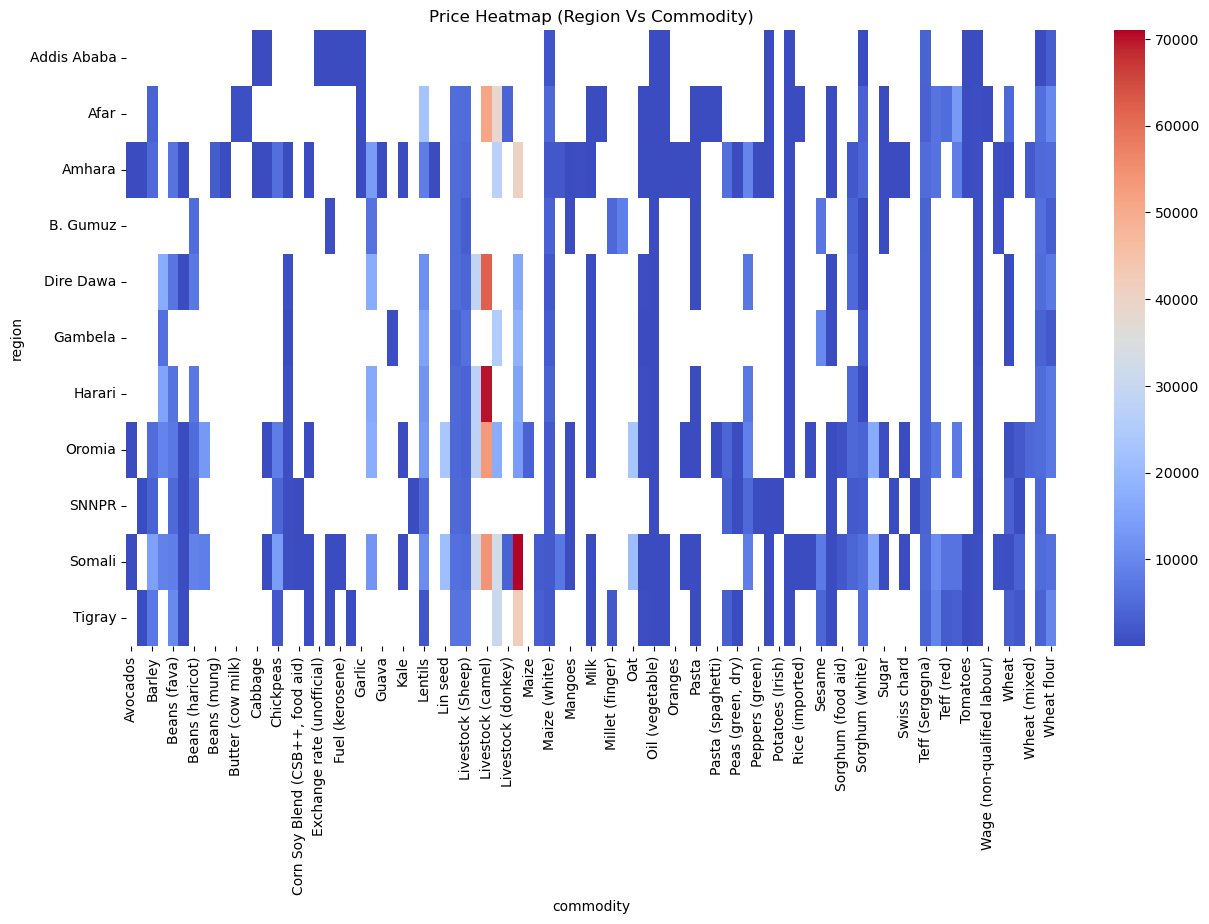

In [45]:
pivot = df.pivot_table(values="price", index="region", columns="commodity")

plt.figure(figsize=(15,8))
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Price Heatmap (Region Vs Commodity)")
plt.show()

### Market Analysis

In [46]:
df.groupby("market")["price"].mean().sort_values().head(10)

market
Gordamole        4.726611
Derashe          4.826585
Kersa           13.151707
Merti           13.167249
Aroresa         22.741221
Kemise          25.895041
Segno Gebeya    27.320946
Nefas Mewcha    49.395833
Flakit          54.112360
Masha           55.003314
Name: price, dtype: float64

#### Key Insights

- Food prices in Ethiopia show a consistent upward trend over time, indicating sustained inflationary pressure on essential commodities.

- Price distribution is highly skewed, with extreme outliers driven primarily by high-value commodities such as livestock, suggesting the need to analyze commodity groups separately for more accurate insights.

- Livestock commodities (camel, cattle, ox) significantly dominate the upper price range, while staple foods such as maize and grains remain more stable and widely available.

- There are substantial regional disparities in food prices, which may reflect differences in supply chains, transportation costs, and local economic conditions.

- Market-level analysis reveals localized price variations, indicating that food affordability can differ significantly even within the same region.

- The widespread presence and relatively stable pricing of maize suggest it is a key staple food in Ethiopia, playing a critical role in food security.

- The dataset includes both food commodities and livestock, which creates scale differences in pricing. Future analysis should segment commodities into categories (e.g., grains vs livestock) to improve analytical accuracy.
    
#### Insights

- Food prices in Ethiopia are rising over time, pointing to inflationary trends.
- Certain commodities (especially livestock) dominate the high-price segment.
- Regional and market-level differences highlight local economic disparites.
- Commodity diversity and frequency suggest maize is a staple with widespread availablity.

#### Limitations

- The dataset combines different types of commodities (food vs livestock), which may distort overall price comparisons.
- Price variations may be influenced by missing contextual factors such as seasonality, transportation costs, and market demand.
- Some extreme outliers may affect average-based analysis.

## Surface-level EDA into deeper analysis

### Explore Distributions

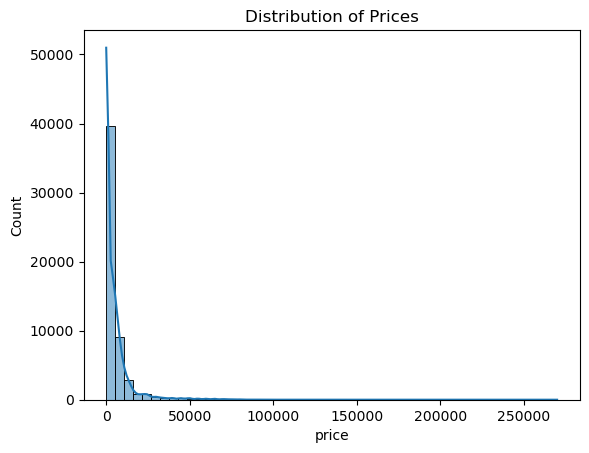

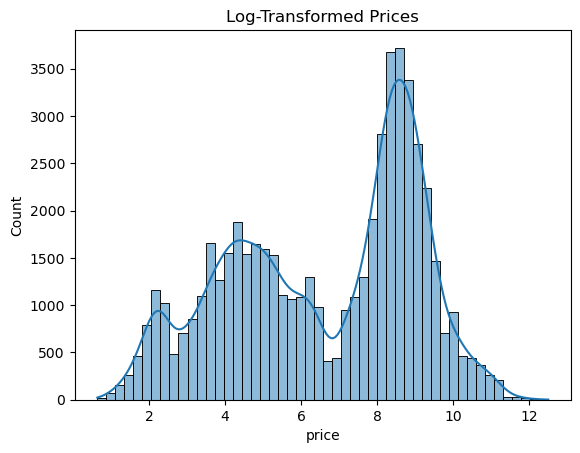

In [47]:
# Histogram of prices
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Prices")
plt.show();

# Log-transformed distribution: to handle zeros in the data
sns.histplot(np.log1p(df["price"]), bins=50, kde=True)
plt.title("Log-Transformed Prices")
plt.show();

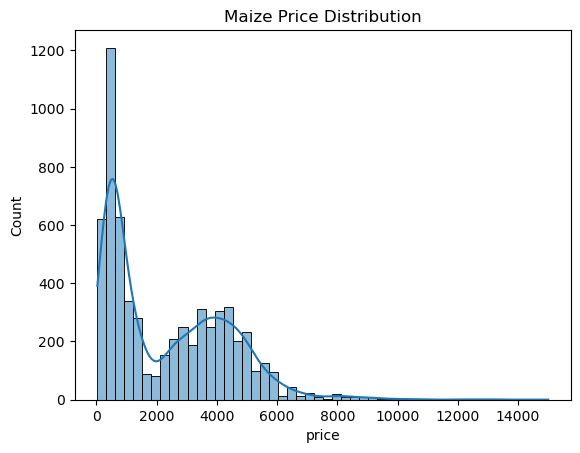

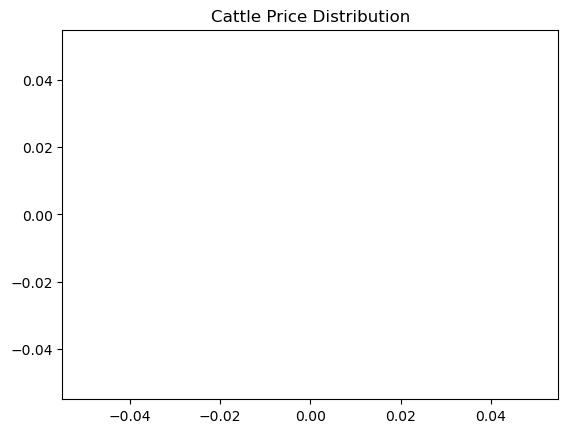

In [48]:
# Example: maize and cattle
sns.histplot(df[df["commodity"]=="Maize (white)"]["price"], bins=50, kde=True)
plt.title("Maize Price Distribution")
plt.show()

sns.histplot(df[df["commodity"]=="Cattle"]["price"], bins=50, kde=True)
plt.title("Cattle Price Distribution")
plt.show()

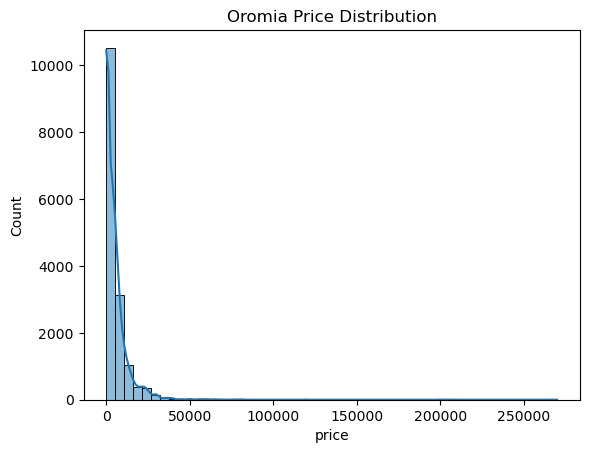

In [49]:
# Segment by Region
sns.histplot(df[df["region"]=="Oromia"]["price"], bins=50, kde=True)
plt.title("Oromia Price Distribution")
plt.show()

In [50]:
import scipy.stats as stats

# Fit lognormal to maize prices
maize_prices = df[df['commodity']=='Maize (white)']['price']
shape, loc, scale = stats.lognorm.fit(maize_prices, floc=0)
print("Lognormal fit params:", shape, loc, scale)


Lognormal fit params: 1.1046597809544383 0.0 1432.023804443154


### Outlier detection and handling

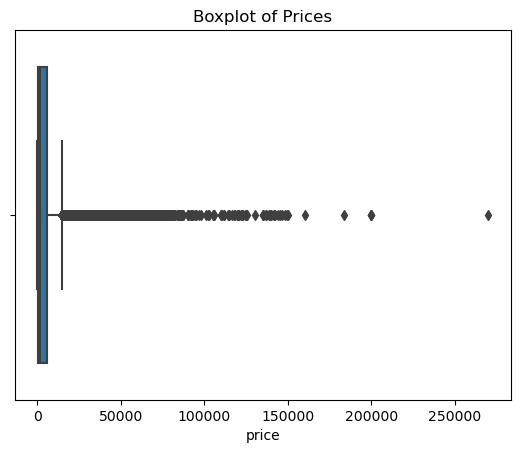

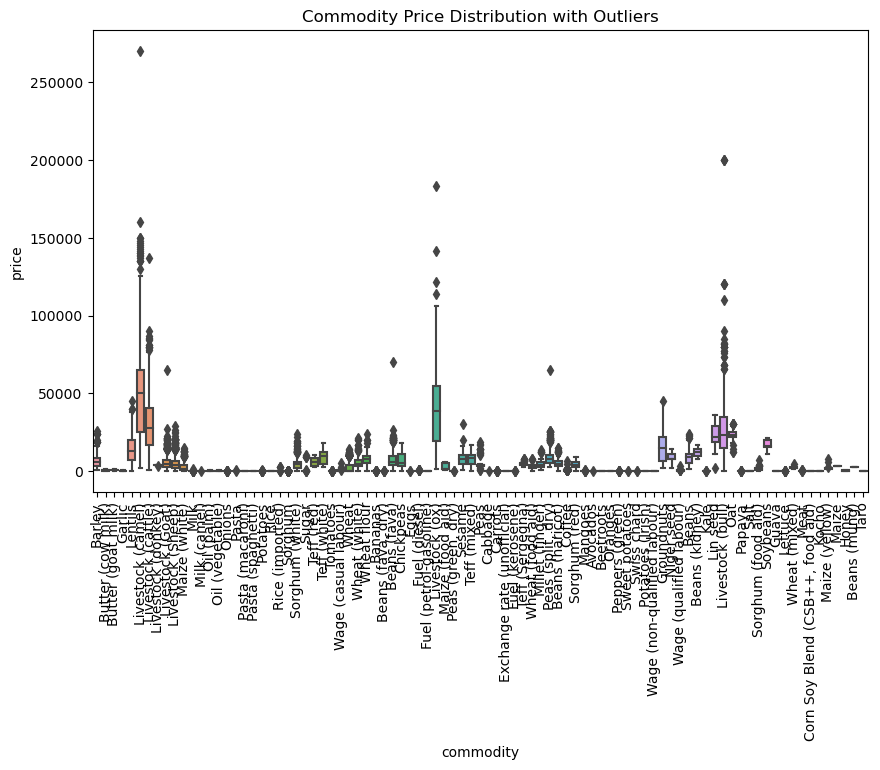

In [51]:
# Visualize Outliers

# Boxplot for overall prices
sns.boxplot(x=df["price"])
plt.title("Boxplot of Prices")
plt.show()

# Commodity-specific boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(x="commodity", y="price", data=df)
plt.xticks(rotation=90)
plt.title("Commodity Price Distribution with Outliers")
plt.show()

In [52]:
# Detect Outliers (IQR Method)

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["price"] < Q1 - 1.5 * IQR) | (df["price"] > Q3 + 1.5 * IQR)]
print(outliers)
print("Outliers count: ", len(outliers))

        country  region  market       commodity price_type       date  \
13     Ethiopia    Afar  Abaala         Lentils     Retail 2024-05-15   
15     Ethiopia    Afar  Abaala         Lentils     Retail 2024-07-15   
16     Ethiopia    Afar  Abaala         Lentils     Retail 2024-08-15   
17     Ethiopia    Afar  Abaala         Lentils     Retail 2024-09-15   
18     Ethiopia    Afar  Abaala         Lentils     Retail 2024-10-15   
...         ...     ...     ...             ...        ...        ...   
53773  Ethiopia  Tigray   Wukro  Livestock (ox)     Retail 2026-03-15   
53774  Ethiopia  Tigray   Wukro  Livestock (ox)     Retail 2026-04-15   
53775  Ethiopia  Tigray   Wukro  Livestock (ox)     Retail 2026-05-15   
53776  Ethiopia  Tigray   Wukro  Livestock (ox)     Retail 2026-06-15   
53777  Ethiopia  Tigray   Wukro  Livestock (ox)     Retail 2026-07-15   

            price  year  month  
13     20000.0000  2024      5  
15     15000.0000  2024      7  
16     16000.0000  2024 

##### Decide What To Do
- Keep → if they represent real events (livestock, drought spikes).
- Remove → if they’re data entry errors (e.g., price = 270,000 for maize).
- Cap/Transform → winsorize or log-scale to reduce distortion.

In [53]:
# Winsorize (cap extreme values)
upper_cap = Q3 + 1.5 * IQR
df["Price_capped"] = np.where(df["price"] > upper_cap, upper_cap, df["price"])

In [54]:
df.rename(columns={"Price_capped": "price_capped"}, inplace=True)

In [55]:
df.columns

Index(['country', 'region', 'market', 'commodity', 'price_type', 'date',
       'price', 'year', 'month', 'price_capped'],
      dtype='object')

In [56]:
print(upper_cap)

14865.0


In [57]:
# Outliers per commodity
outlier_counts = outliers["commodity"].value_counts()
print(outlier_counts.head(10))

Livestock (cattle)    717
Livestock (bull)      597
Livestock (ox)        480
Lentils               461
Livestock (camel)     461
Groundnuts            431
Beans (fava)          118
Peas (split, dry)     107
Teff (white)           52
Oat                    50
Name: commodity, dtype: int64


### Time Series Analysis

In [58]:
# Clean chronological order for analysis
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

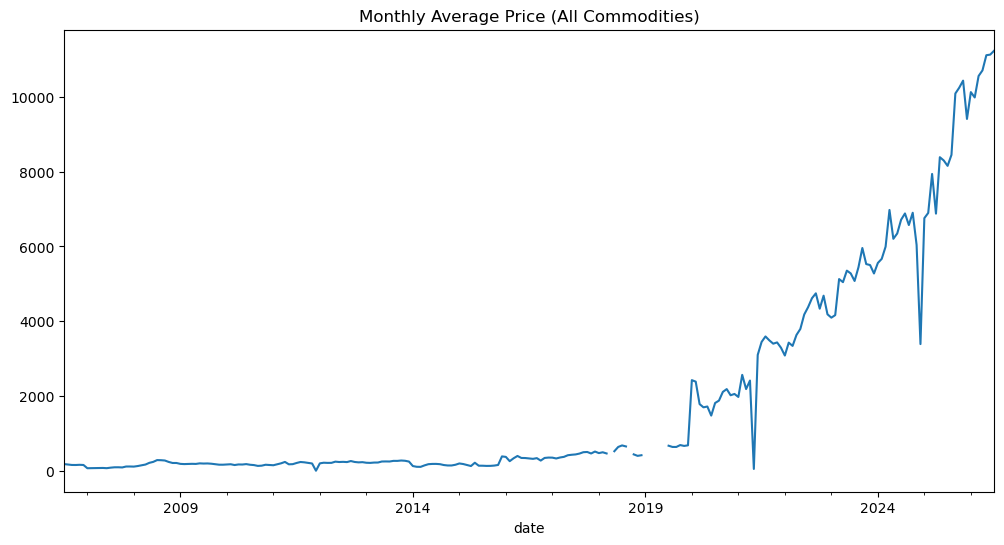

In [59]:
# Aggregate by Time
# Monthly average price accross all commodities 
monthly = df.resample("M", on="date")["price"].mean()

monthly.plot(figsize=(12, 6))
plt.title("Monthly Average Price (All Commodities)")
plt.show()

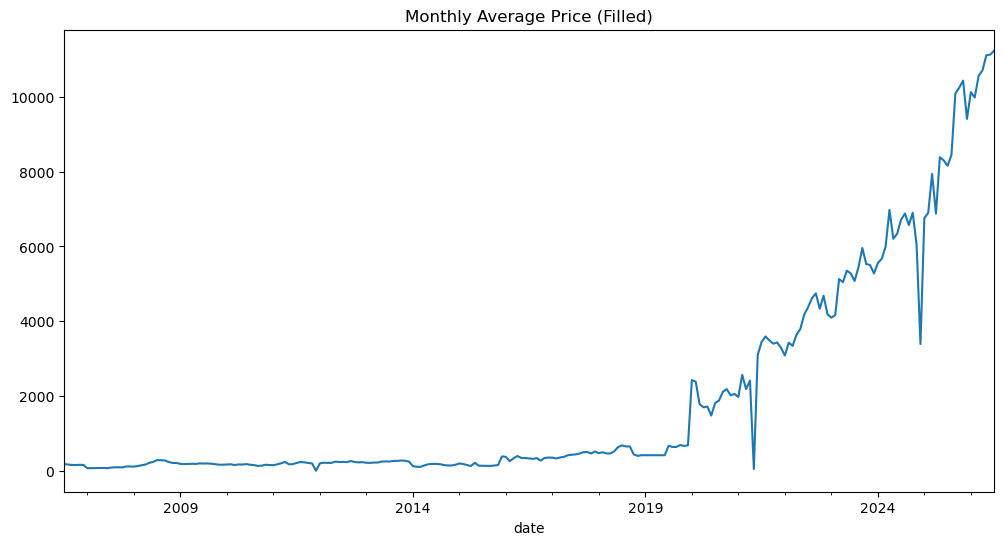

In [60]:
# Handling missing Months
# Ensure continuous monthly index
monthly = df.resample("M", on="date")["price"].mean()

# Fill missing values with forward/backward fill
monthly_filled = monthly.fillna(method="ffill").fillna(method="bfill")

monthly_filled.plot(figsize=(12, 6))
plt.title("Monthly Average Price (Filled)")
plt.show()

In [61]:
# Check Commodity Coverage
# Count entries per year
df["year"] = df["date"].dt.year
print(df.groupby("year")["commodity"].nunique())

year
2006     1
2007     3
2008     3
2009     3
2010     3
2011     3
2012     3
2013     3
2014    15
2015    22
2016    15
2017    14
2018    14
2019    14
2020    80
2021    64
2022    62
2023    62
2024    63
2025    62
2026    65
Name: commodity, dtype: int64


In [62]:
# Annotate Missing Periods
missing_months = monthly[monthly.isna()]
print("Missing months: ", missing_months.index)

Missing months:  DatetimeIndex(['2018-04-30', '2018-09-30', '2019-01-31', '2019-02-28',
               '2019-03-31', '2019-04-30', '2019-05-31', '2019-06-30'],
              dtype='datetime64[ns]', name='date', freq=None)


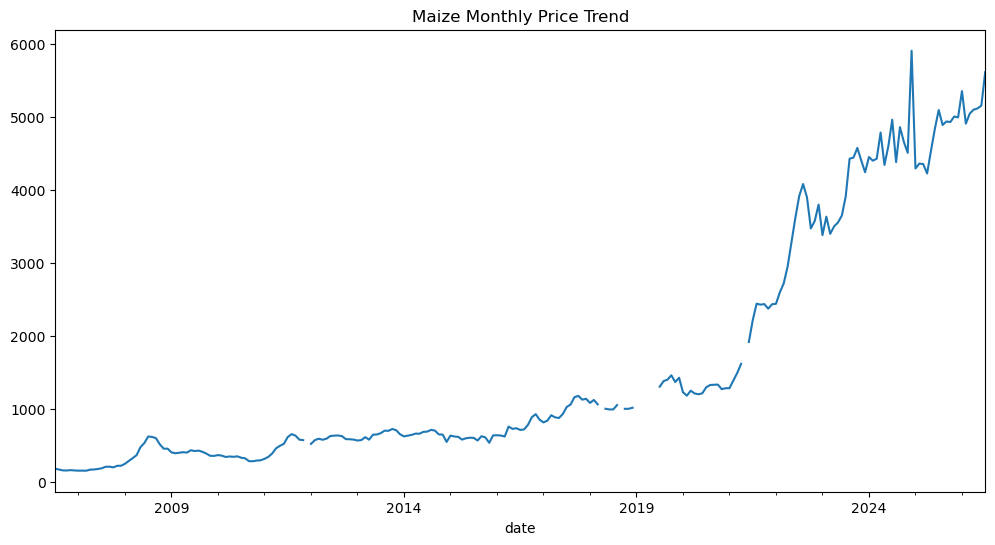

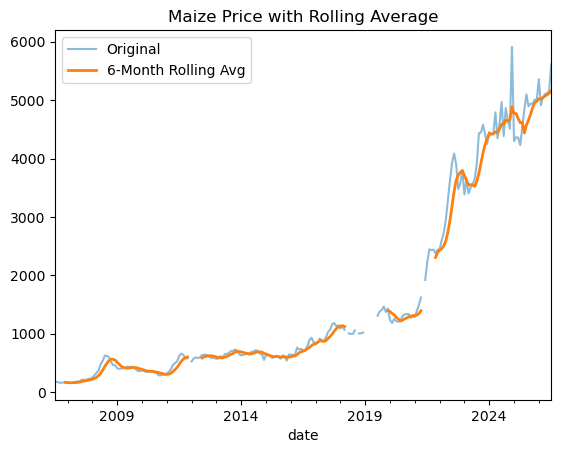

In [63]:
# Example: Maize
maize = df[df['commodity']=='Maize (white)'].resample('M', on='date')['price'].mean()
maize.plot(figsize=(12,6))
plt.title("Maize Monthly Price Trend")
plt.show()

maize_rolling = maize.rolling(window=6).mean()
maize.plot(label='Original', alpha=0.5)
maize_rolling.plot(label='6-Month Rolling Avg', linewidth=2)
plt.legend()
plt.title("Maize Price with Rolling Average")
plt.show()


# Visualization

### Time Trend

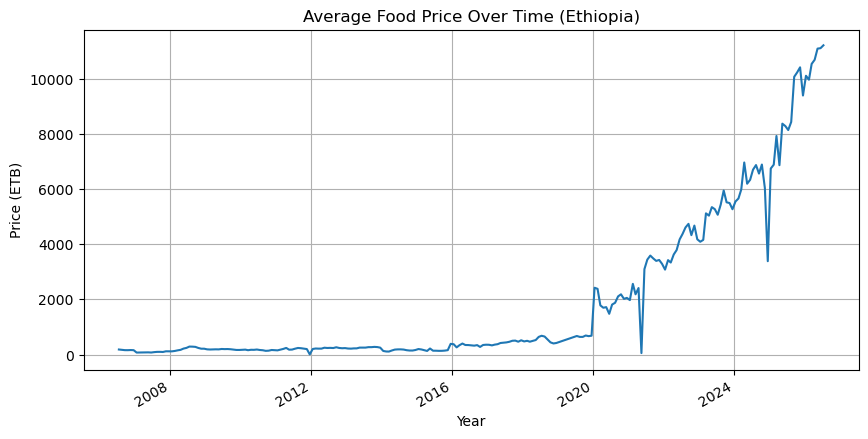

In [66]:
price_trend = df.groupby("date")["price"].mean()

plt.figure(figsize=(10, 5))
price_trend.plot()
plt.title("Average Food Price Over Time (Ethiopia)")
plt.xlabel("Year")
plt.ylabel("Price (ETB)")
plt.grid()
plt.show();

##### The consistent upward trend indicates sustained inflation in food price, ehich may reduce purchasing power for customers over time.

### Commodity Comparison

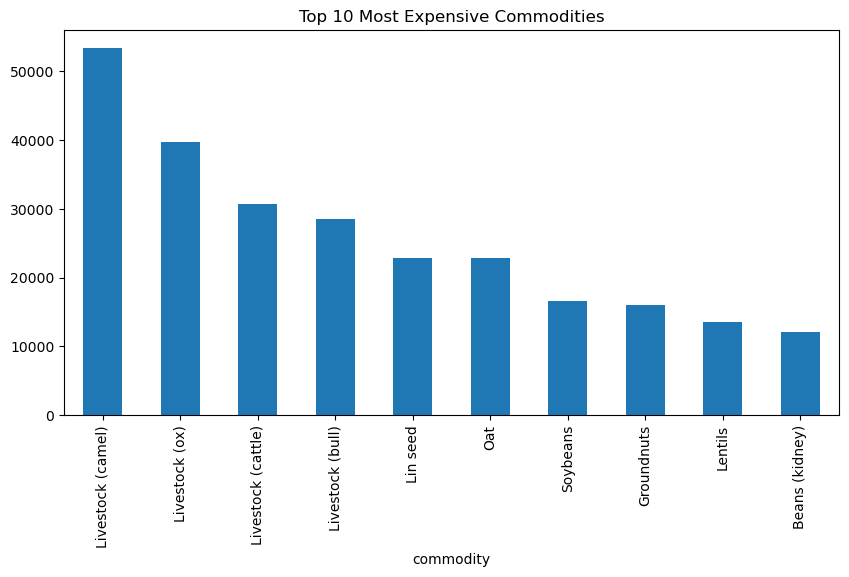

In [69]:
top_items = df.groupby("commodity")["price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_items.plot(kind="bar")
plt.title("Top 10 Most Expensive Commodities")
plt.show()

##### Livestock commodities dominate the upper price range, reflecting their higher economic value compared to staple foods.

### Region Comparison

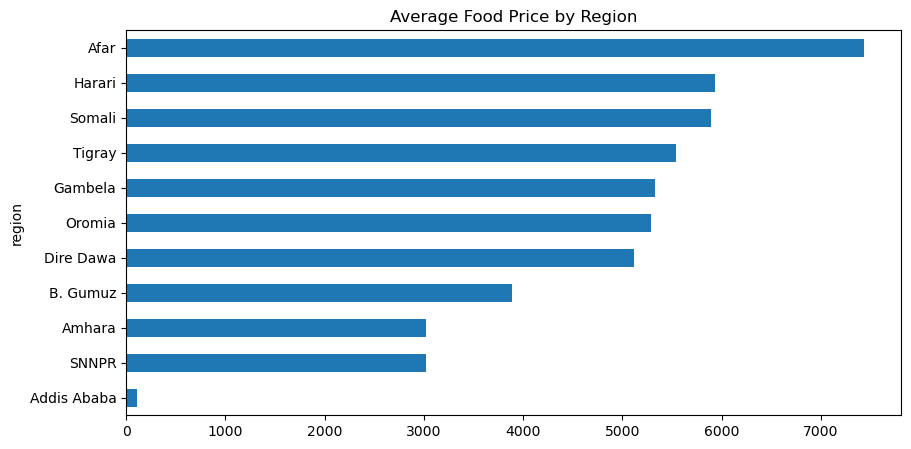

In [70]:
region_price = df.groupby("region")["price"].mean().sort_values()

plt.figure(figsize=(10, 5))
region_price.plot(kind="barh")
plt.title("Average Food Price by Region")
plt.show()

##### Significant regional disparties suggest differences in supply chains, transportation costs, or local economic conditions.

### Advanced

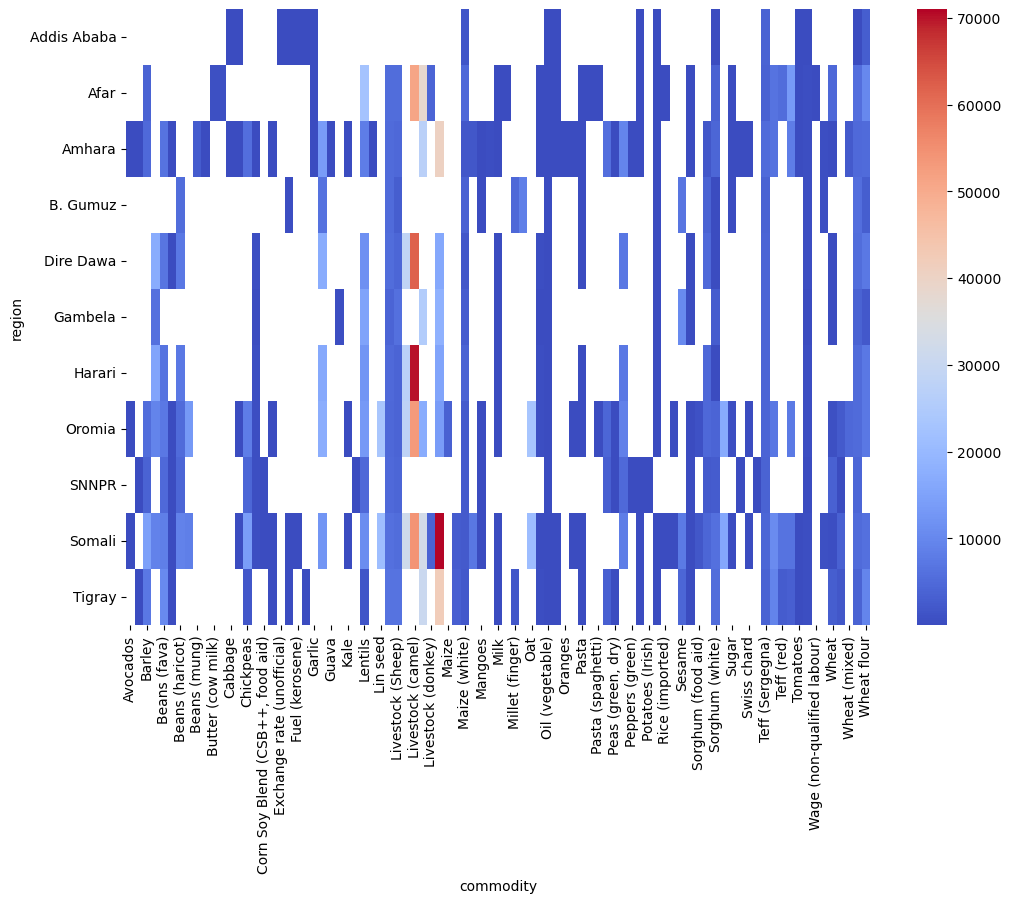

In [73]:
pivot = df.pivot_table(values="price", index="region", columns="commodity")

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap="coolwarm");

##### Price variation across the regions and commodities indicates localized market dynamics rather than uniform national pricing.